In [2]:
from operator import index

from matplotlib.ticker import scale_range
from pyspark.sql import SparkSession

spark = SparkSession.builder.appName("housePrice").getOrCreate()
df = (spark.read.option("header", "true").option("inferSchema", "true").
      csv("file:///D:/code/python/BigDataDevelopment/《大数据开发课程设计》期末考核试卷2025/Data/house_prices.csv"))

In [3]:
df.head(10)

[Row(_c0=0, property_type='Flat', price=10000000, location='G-10', city='Islamabad', baths=2, purpose='For Sale', bedrooms=2, Area_in_Marla=4.0),
 Row(_c0=1, property_type='Flat', price=6900000, location='E-11', city='Islamabad', baths=3, purpose='For Sale', bedrooms=3, Area_in_Marla=5.6),
 Row(_c0=2, property_type='House', price=16500000, location='G-15', city='Islamabad', baths=6, purpose='For Sale', bedrooms=5, Area_in_Marla=8.0),
 Row(_c0=3, property_type='House', price=43500000, location='Bani Gala', city='Islamabad', baths=4, purpose='For Sale', bedrooms=4, Area_in_Marla=40.0),
 Row(_c0=4, property_type='House', price=7000000, location='DHA Defence', city='Islamabad', baths=3, purpose='For Sale', bedrooms=3, Area_in_Marla=8.0),
 Row(_c0=7, property_type='Flat', price=7800000, location='E-11', city='Islamabad', baths=2, purpose='For Sale', bedrooms=2, Area_in_Marla=6.2),
 Row(_c0=9, property_type='Penthouse', price=40000000, location='F-11', city='Islamabad', baths=5, purpose='For

In [4]:
df.printSchema()

root
 |-- _c0: integer (nullable = true)
 |-- property_type: string (nullable = true)
 |-- price: integer (nullable = true)
 |-- location: string (nullable = true)
 |-- city: string (nullable = true)
 |-- baths: integer (nullable = true)
 |-- purpose: string (nullable = true)
 |-- bedrooms: integer (nullable = true)
 |-- Area_in_Marla: double (nullable = true)



In [5]:
df.columns

['_c0',
 'property_type',
 'price',
 'location',
 'city',
 'baths',
 'purpose',
 'bedrooms',
 'Area_in_Marla']

In [6]:
df.count()

99499

In [7]:
len(df.columns)

9

In [8]:
df.describe().show()

+-------+------------------+-------------+--------------------+-------------+----------+------------------+--------+------------------+-----------------+
|summary|               _c0|property_type|               price|     location|      city|             baths| purpose|          bedrooms|    Area_in_Marla|
+-------+------------------+-------------+--------------------+-------------+----------+------------------+--------+------------------+-----------------+
|  count|             99499|        99499|               99499|        99499|     99499|             99499|   99499|             99499|            99499|
|   mean|  78883.8930642519|         null|1.0375919495974833E7|         null|      null|3.5301058302093486|    null|3.3507371933386265|8.757478969637763|
| stddev|48239.423663195965|         null|1.0659998262207817E7|         null|      null|1.4742169870119386|    null|1.2559131617974093|7.466470982242494|
|    min|                 0|   Farm House|               15500|  12th Avenue

In [9]:
crosstab = df.crosstab("property_type", "purpose")
crosstab.show()

+---------------------+--------+--------+
|property_type_purpose|For Rent|For Sale|
+---------------------+--------+--------+
|           Farm House|      13|      75|
|                 Flat|    7275|   19383|
|            Penthouse|      71|     184|
|                 Room|     229|      12|
|                House|    9147|   49022|
|        Upper Portion|    6928|    1611|
|        Lower Portion|    4889|     660|
+---------------------+--------+--------+



In [10]:
city_price_avg = df.groupBy("city").agg({"price": "avg"}).orderBy("avg(price)", ascending=False).toPandas()
city_price_avg

,city,avg(price)
0,Lahore,1.678080e+07
1,Karachi,9.498481e+06
2,Rawalpindi,7.926352e+06
3,Faisalabad,7.799314e+06
4,Islamabad,5.838865e+06


C:\Users\MouKexin\AppData\Local\Temp\ipykernel_30420\412645125.py:5: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(city_data, labels=city_price_avg["city"])


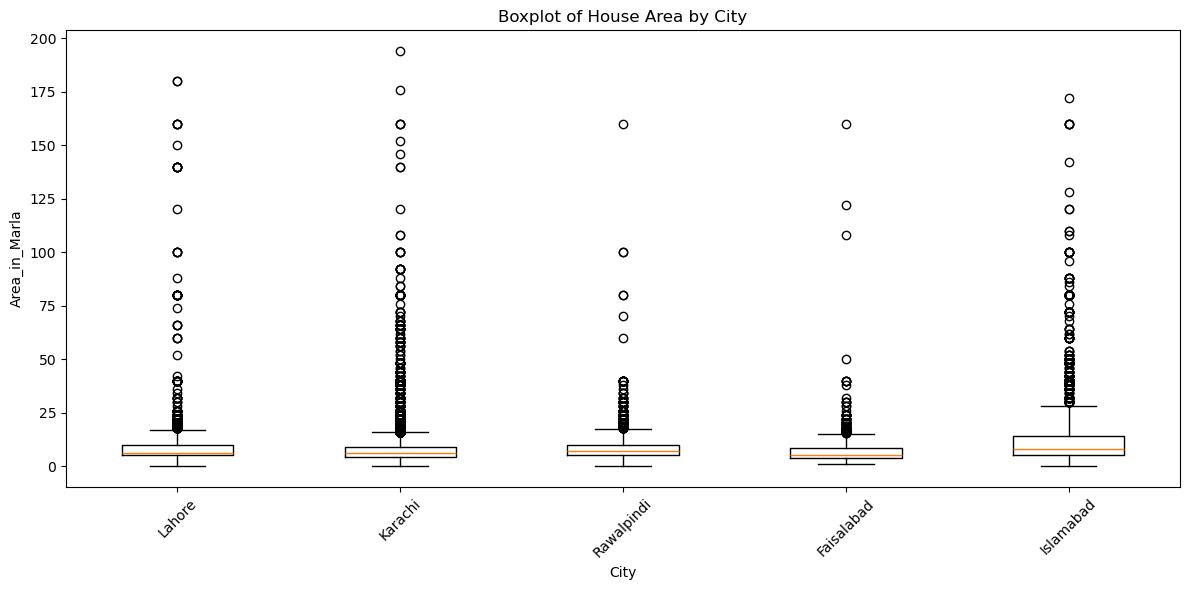

In [11]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))
city_data = [df.filter(df.city == city).select("Area_in_Marla").toPandas()["Area_in_Marla"].dropna() for city in city_price_avg["city"]]
plt.boxplot(city_data, labels=city_price_avg["city"])
plt.xticks(rotation=45)
plt.xlabel("City")
plt.ylabel("Area_in_Marla")
plt.title("Boxplot of House Area by City")
plt.tight_layout()
plt.show()

In [21]:
new_df = df.select("city", "price", "property_type").filter(df.property_type == "House")
new_df = new_df.dropDuplicates()
new_df.toPandas().head()

,city,price,property_type
0,Islamabad,26900000,House
1,Islamabad,37900000,House
2,Rawalpindi,27800000,House
3,Islamabad,29000000,House
4,Faisalabad,29000000,House


In [22]:
new_df.toPandas().to_csv("filtered_houses.csv", index=False)

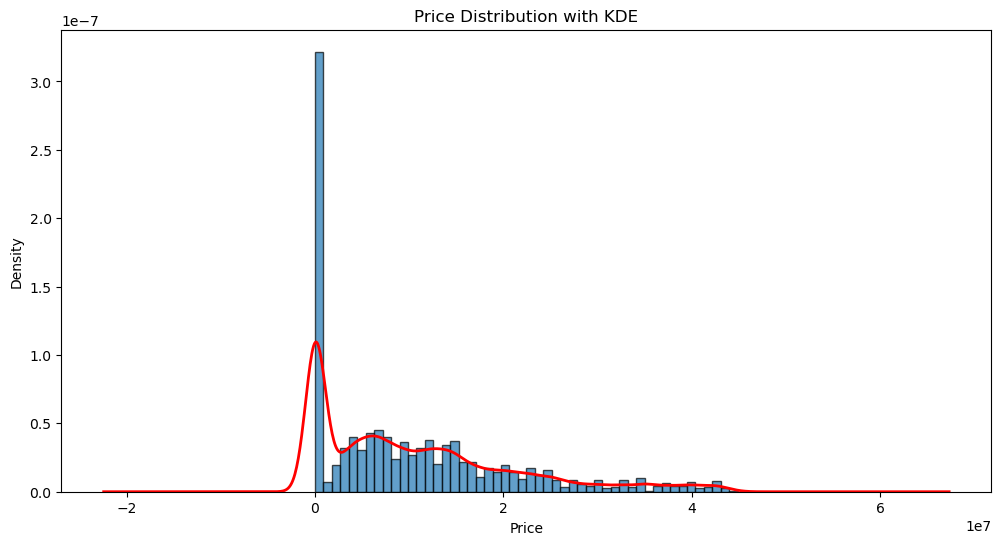

In [23]:
import matplotlib.pyplot as plt

pdf = df.select("price").toPandas()
plt.figure(figsize=(12, 6))
plt.hist(pdf["price"], bins=50, density=True, alpha=0.7, edgecolor='black')
pdf["price"].plot.kde(color='red', linewidth=2)
plt.xlabel('Price')
plt.ylabel('Density')
plt.title('Price Distribution with KDE')
plt.show()